Shooting method iterations:
iter =  0 | theta = 0.017453293 rad (1.000000 deg)
iter =  1 | theta = -0.013577733 rad (-0.777947 deg)

Final theta: -0.013577733 rad (-0.777947 deg)


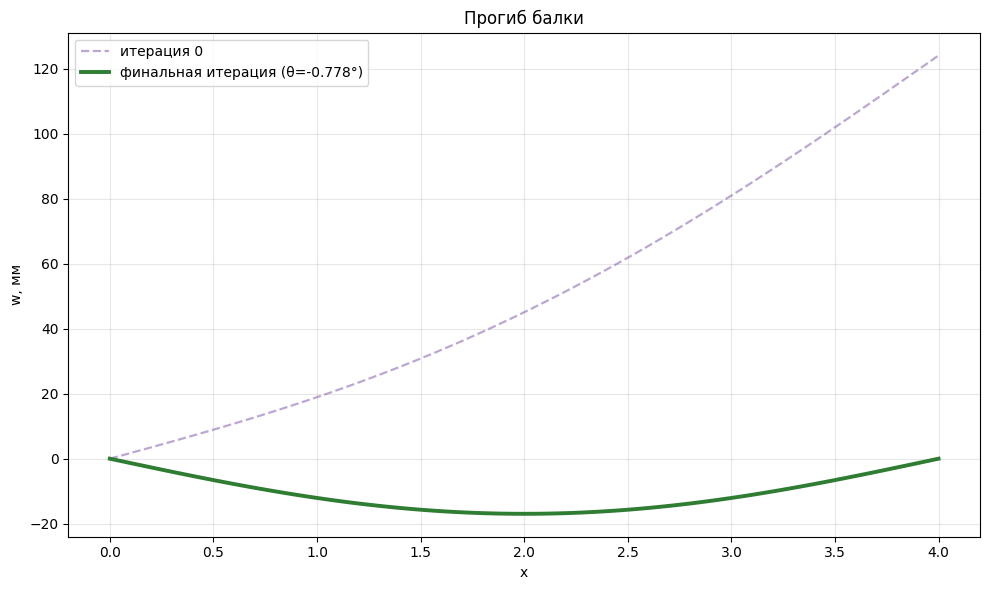

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def calc_displacements(w_0, theta_0, EJ, L):
    sol_0 = np.array((w_0, theta_0), dtype=np.float64)
    x_0, x_1 = 0.0, L
    N = 100
    h = (x_1 - x_0) / N
    x = np.linspace(x_0, x_1, N + 1)

    sol_rk4 = np.zeros((N + 1, 2), dtype=np.float64)
    sol_rk4[0] = sol_0

    q = 5000.0
    def M(x):
        return 0.5 * q * (L*x - x*x)

    def f(s, x):
        w, theta = s
        return np.array((theta, M(x) / EJ))

    for i in range(N):
        x_i = x[i]
        s0 = sol_rk4[i]
        d1 = h * f(s0,               x_i)
        d2 = h * f(s0 + 0.5*d1,      x_i + 0.5*h)
        d3 = h * f(s0 + 0.5*d2,      x_i + 0.5*h)
        d4 = h * f(s0 + d3,          x_i + h)
        sol_rk4[i+1] = s0 + (d1 + 2*d2 + 2*d3 + d4) / 6.0

    return x, sol_rk4

def shooting_method():
    EJ = 9.82e5
    L = 4.0
    w_0 = 0.0
    w_L = 0.0
    max_iter = 100
    iter_count = 0
    theta = np.radians(1.0)
    dh = np.radians(90.0) / 100
    iterations_data = []
    x_mesh = None

    print("Shooting method iterations:")
    while iter_count < max_iter:
        x, sol_rk4_p = calc_displacements(w_0, theta + dh, EJ, L)
        x, sol_rk4_m = calc_displacements(w_0, theta - dh, EJ, L)
        x, sol_rk4_0 = calc_displacements(w_0, theta, EJ, L)
        if x_mesh is None:
            x_mesh = x
        print(f"iter = {iter_count:2d} | theta = {theta:.9f} rad ({np.degrees(theta):.6f} deg)")

        f_p = sol_rk4_p[-1,0] - w_L
        f_m = sol_rk4_m[-1,0] - w_L
        f_0 = sol_rk4_0[-1,0] - w_L

        derivative = (f_p - f_m) / (2.0 * dh)
        delta = f_0 / derivative
        theta = theta - delta

        iterations_data.append({
            'iteration': iter_count,
            'theta': theta,
            'trajectory': sol_rk4_0,
            'error': f_0,
            'delta': delta
        })
        if abs(delta) < 1e-8:
            break
        iter_count += 1

    print(f"\nFinal theta: {theta:.9f} rad ({np.degrees(theta):.6f} deg)")
    return iterations_data, x_mesh, theta

iterations_data, x, theta = shooting_method()

plt.figure(figsize=(10, 6))
for i, data in enumerate(iterations_data):
    w = data['trajectory'][:, 0] * 1000  # мм
    if i == len(iterations_data) - 1:
        plt.plot(x, w, color="#2E7D32", linewidth=2.8, label=f"финальная итерация (θ={np.degrees(theta):.3f}°)")
    else:
        plt.plot(x, w, linestyle="--", linewidth=1.6, alpha=0.45, color="#6A3D9A", label=f"итерация {i}")
plt.xlabel("x"); plt.ylabel("w, мм")
plt.title("Прогиб балки")
plt.grid(True, alpha=0.3)
handles, labels = plt.gca().get_legend_handles_labels()
if len(handles) > 2:
    handles = [handles[0], handles[-1]]
    labels = [labels[0], labels[-1]]
plt.legend(handles, labels)
plt.tight_layout(); plt.show()
